# Credit Default Prediction and Loan Pre-Screening Model (Upgraded)
### Aman Aggarwal (065064) | PGDM (BDA) 2025-27 | FORE School of Management

This notebook upgrades my earlier Deep Learning (DLM) project on credit default prediction using a PyTorch ANN. It fixes the issues found in the original version, compares models fairly, adds explainability, and produces a trained model that powers a customer-facing **Loan Eligibility Pre-Screener** app (AI Application end-term project).

**What changed from the original project**

| Area | Original DLM notebook | This upgraded version |
|---|---|---|
| Data quality | Impossible ages (up to 144) and employment lengths (123 years) left in; 165 duplicate rows kept | Duplicates removed, impossible values cleaned with documented rules |
| Feature engineering | Engineered features were created after the model inputs were already fixed, so they did not reach the model | Features built in a reusable function inside the pipeline, so they reach every model and the app |
| Leakage | Used loan grade and interest rate, which the lender assigns only after assessing the borrower | Pre-screening model uses only what a customer knows; the effect of leakage is measured and reported |
| Model comparison | Unweighted Logistic Regression vs weighted ANN (unfair); the notebook's own AUCs (LR 0.868 vs ANN 0.84) contradicted the "ANN is superior" conclusion | LR, ANN and XGBoost all handle imbalance the same way and are compared on the same validation and test sets |
| ANN training | 30 full-batch epochs, no validation set | Mini-batches, validation set, early stopping, best-model restore |
| Decision output | Single 0.5 threshold | Calibrated probability, three business bands, plus hard policy rules |
| Explainability | None | SHAP, globally and for individual applicants |
| Deployment | Described in text only | Model, settings and shared code saved for the Streamlit app |

**Data:** Kaggle `credit_risk_dataset.csv` (32,581 loan records). This is a US dataset with amounts in US dollars, used here as demonstration data.

## 1. Setup

Run this notebook in Google Colab (Runtime, then Run all). It reads the dataset from `MyDrive/Loan_Prescreener/` and saves all outputs back to that same folder, so nothing is lost when the Colab session ends.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/Loan_Prescreener"
except ImportError:          # running locally (e.g. VS Code on the Mac)
    BASE = os.getcwd()

os.chdir(BASE)
os.makedirs("artifacts", exist_ok=True)
print("Working folder:", BASE)
print("Files:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working folder: /content/drive/MyDrive/Loan_Prescreener
Files: ['credit_risk_dataset.csv', 'artifacts']


In [2]:
try:
    import xgboost, shap
except ImportError:
    %pip -q install xgboost shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                             precision_score, f1_score, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import torch, torch.nn as nn
import shap, joblib

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
print("xgboost", xgb.__version__, "| torch", torch.__version__, "| shap", shap.__version__)

xgboost 3.4.1 | torch 2.11.0+cpu | shap 0.52.0


### 1.1 Shared code module

The feature engineering, input validation, policy rules and the model wrapper live in one file, `loan_model.py`. The notebook writes it to the project folder and imports it. The Streamlit app will import the **same file**, which guarantees the app treats applicants exactly as the model was trained. (It also allows the saved model to be loaded correctly outside this notebook.)

In [4]:
%%writefile loan_model.py
"""
loan_model.py
Shared logic for the Loan Eligibility Pre-Screener.
Used by BOTH the training notebook and the Streamlit app, so the app
applies exactly the same feature engineering, validation and policy rules.
Author: Aman Aggarwal (065064), FORE School of Management
"""
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 1. Feature definitions
# ---------------------------------------------------------------
# Inputs a customer can answer at pre-screening time
NUM_INPUTS = ["person_age", "person_income", "person_emp_length",
              "loan_amnt", "cb_person_cred_hist_length"]
CAT_INPUTS = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]

# Assigned by the lender AFTER assessment, so NOT available at pre-screening
LENDER_NUM = ["loan_int_rate"]
LENDER_CAT = ["loan_grade"]

ENGINEERED = ["loan_to_income", "log_income", "log_loan", "emp_to_age",
              "hist_to_age", "high_burden", "prior_default_high_burden"]

CATEGORIES = {
    "person_home_ownership": ["RENT", "MORTGAGE", "OWN", "OTHER"],
    "loan_intent": ["EDUCATION", "MEDICAL", "VENTURE", "PERSONAL",
                    "DEBTCONSOLIDATION", "HOMEIMPROVEMENT"],
    "cb_person_default_on_file": ["N", "Y"],
}


def add_features(X):
    """Create engineered features. Uses no statistics from the data,
    so it can be applied before or after the train/test split without leakage."""
    X = X.copy()
    X["loan_to_income"] = X["loan_amnt"] / X["person_income"]
    X["log_income"] = np.log1p(X["person_income"])
    X["log_loan"] = np.log1p(X["loan_amnt"])
    X["emp_to_age"] = X["person_emp_length"] / X["person_age"]
    X["hist_to_age"] = X["cb_person_cred_hist_length"] / X["person_age"]
    X["high_burden"] = (X["loan_to_income"] > 0.4).astype(int)
    X["prior_default_high_burden"] = ((X["cb_person_default_on_file"] == "Y")
                                      & (X["loan_to_income"] > 0.3)).astype(int)
    return X


def feature_lists(include_lender_fields=False):
    num = NUM_INPUTS + ENGINEERED + (LENDER_NUM if include_lender_fields else [])
    cat = CAT_INPUTS + (LENDER_CAT if include_lender_fields else [])
    return num, cat


# ---------------------------------------------------------------
# 2. Human-readable names (used for explanations)
# ---------------------------------------------------------------
GROUP_OF = {"log_income": "person_income", "log_loan": "loan_amnt"}
FRIENDLY = {
    "person_age": "Age",
    "person_income": "Annual income",
    "person_emp_length": "Years in employment",
    "loan_amnt": "Loan amount requested",
    "cb_person_cred_hist_length": "Length of credit history",
    "loan_to_income": "Loan-to-income ratio",
    "emp_to_age": "Employment stability",
    "hist_to_age": "Credit history relative to age",
    "high_burden": "High repayment burden",
    "prior_default_high_burden": "Past default combined with high burden",
    "person_home_ownership": "Home ownership",
    "loan_intent": "Loan purpose",
    "cb_person_default_on_file": "Previous default on record",
    "loan_grade": "Loan grade",
    "loan_int_rate": "Interest rate",
}
ALL_BASE = NUM_INPUTS + CAT_INPUTS + LENDER_NUM + LENDER_CAT + ENGINEERED


def base_feature(transformed_name):
    """Map a transformed column (e.g. 'cat__loan_intent_MEDICAL') to its base input."""
    name = transformed_name.split("__", 1)[-1]
    for col in sorted(ALL_BASE, key=len, reverse=True):
        if name == col or name.startswith(col + "_"):
            return GROUP_OF.get(col, col)
    return name


# ---------------------------------------------------------------
# 3. The deployable model object
# ---------------------------------------------------------------
class LoanRiskModel:
    """Preprocessor + classifier + probability calibrator in one object."""

    def __init__(self, preprocessor, classifier, calibrator, kind, feature_names):
        self.preprocessor = preprocessor
        self.classifier = classifier
        self.calibrator = calibrator
        self.kind = kind                    # "xgboost" or "logistic"
        self.feature_names = list(feature_names)

    def _transform(self, X):
        return self.preprocessor.transform(X)

    def raw_score(self, X):
        return self.classifier.predict_proba(self._transform(X))[:, 1]

    def predict_pd(self, X):
        """Calibrated probability of default."""
        return self.calibrator.predict(self.raw_score(X))

    def explain(self, X, top_n=5):
        """Per-applicant contributions (log-odds scale), grouped to base inputs.
        Positive = pushes risk UP, negative = pushes risk DOWN."""
        Xt = self._transform(X)
        if self.kind == "xgboost":
            import xgboost as xgb
            booster = self.classifier.get_booster()
            it = getattr(self.classifier, "best_iteration", None)
            rng = (0, it + 1) if it is not None else (0, 0)
            contrib = booster.predict(xgb.DMatrix(Xt), pred_contribs=True,
                                      iteration_range=rng)[:, :-1]
        elif self.kind == "logistic":
            contrib = Xt * self.classifier.coef_[0]
        else:
            raise NotImplementedError(self.kind)
        out = []
        for row in np.atleast_2d(contrib):
            agg = {}
            for name, v in zip(self.feature_names, row):
                b = base_feature(name)
                agg[b] = agg.get(b, 0.0) + float(v)
            ranked = sorted(agg.items(), key=lambda kv: abs(kv[1]), reverse=True)[:top_n]
            out.append([(FRIENDLY.get(k, k), round(v, 3)) for k, v in ranked])
        return out


# ---------------------------------------------------------------
# 4. Input validation (hard limits: reject impossible inputs)
# ---------------------------------------------------------------
HARD_LIMITS = {
    "person_age": (18, 100),
    "person_income": (1_000, 10_000_000),
    "person_emp_length": (0, 60),
    "loan_amnt": (500, 35_000),          # product limit in the training data
    "cb_person_cred_hist_length": (0, 60),
}


def validate_applicant(a):
    """Return a list of error messages. Empty list = valid."""
    errors = []
    for f, (lo, hi) in HARD_LIMITS.items():
        v = a.get(f)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            errors.append(f"{FRIENDLY[f]} is missing.")
        elif not (lo <= v <= hi):
            errors.append(f"{FRIENDLY[f]} must be between {lo:,} and {hi:,} (got {v:,}).")
    for f, allowed in CATEGORIES.items():
        if a.get(f) not in allowed:
            errors.append(f"{FRIENDLY[f]} must be one of {allowed}.")
    if not errors:
        working_years = a["person_age"] - 14
        if a["person_emp_length"] > working_years:
            errors.append("Years in employment cannot exceed age minus 14.")
        if a["cb_person_cred_hist_length"] > working_years:
            errors.append("Credit history cannot be longer than age minus 14.")
    return errors


# ---------------------------------------------------------------
# 5. Bands and policy rules
# ---------------------------------------------------------------
BANDS = ["Likely eligible", "Needs further review", "Unlikely at this time"]


def model_band(pd_value, t_low, t_high):
    if pd_value >= t_high:
        return 2
    if pd_value >= t_low:
        return 1
    return 0


def policy_checks(a, training_ranges=None):
    """Hard credit-policy rules that override the model (they can only make the
    outcome MORE cautious). Returns (minimum_band, list_of_reasons)."""
    reasons, min_band = [], 0
    lti = a["loan_amnt"] / a["person_income"]
    if lti > 0.5:
        min_band = max(min_band, 1)
        reasons.append("Requested loan is more than 50% of annual income.")
    if a["cb_person_default_on_file"] == "Y" and lti > 0.3:
        min_band = max(min_band, 1)
        reasons.append("Previous default on record combined with a loan above 30% of income.")
    if training_ranges:
        for f, (lo, hi) in training_ranges.items():
            if f in a and not (lo <= a[f] <= hi):
                min_band = max(min_band, 1)
                reasons.append(f"{FRIENDLY.get(f, f)} is outside the range the model "
                               f"was trained on, so a human should check this case.")
    return min_band, reasons


def score_applicant(model, a, config):
    """Full decision flow for ONE applicant (dict of raw inputs)."""
    errors = validate_applicant(a)
    if errors:
        return {"valid": False, "errors": errors}
    X = pd.DataFrame([a])
    pd_value = float(model.predict_pd(X)[0])
    mb = model_band(pd_value, config["t_low"], config["t_high"])
    min_band, reasons = policy_checks(a, config.get("training_ranges"))
    final = max(mb, min_band)
    return {
        "valid": True,
        "probability_of_default": round(pd_value, 4),
        "model_band": BANDS[mb],
        "final_band": BANDS[final],
        "policy_override": final != mb,
        "policy_reasons": reasons,
        "top_drivers": model.explain(X)[0],
    }

Writing loan_model.py


In [5]:
if BASE not in sys.path:
    sys.path.insert(0, BASE)
import importlib, loan_model as lm
importlib.reload(lm)
print("loan_model.py loaded")

loan_model.py loaded


## 2. Data Audit

In [6]:
raw = pd.read_csv("credit_risk_dataset.csv")
print("Shape:", raw.shape)
raw.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(2),
    "min": raw.min(numeric_only=True),
    "max": raw.max(numeric_only=True),
})
print("Duplicate rows:", raw.duplicated().sum())
print("Ages above 100:", (raw.person_age > 100).sum(), "->", sorted(raw.person_age[raw.person_age > 100]))
print("Employment length above age minus 14:", (raw.person_emp_length > raw.person_age - 14).sum())
print("Default rate: {:.1%}".format(raw.loan_status.mean()))
audit

Duplicate rows: 165
Ages above 100: 5 -> [123, 123, 144, 144, 144]
Employment length above age minus 14: 2
Default rate: 21.8%


,dtype,missing,missing_%,min,max
cb_person_cred_hist_length,int64,0,0.00,2.00,30.00
cb_person_default_on_file,object,0,0.00,NaN,NaN
loan_amnt,int64,0,0.00,500.00,35000.00
loan_grade,object,0,0.00,NaN,NaN
loan_int_rate,float64,3116,9.56,5.42,23.22
loan_intent,object,0,0.00,NaN,NaN
loan_percent_income,float64,0,0.00,0.00,0.83
loan_status,int64,0,0.00,0.00,1.00
person_age,int64,0,0.00,20.00,144.00
person_emp_length,float64,895,2.75,0.00,123.00


In [8]:
# loan_percent_income in the file is rounded and occasionally inconsistent with amount / income.
# The app will compute the ratio from what the customer enters, so we recompute it the same way.
diff = (raw.loan_percent_income - raw.loan_amnt / raw.person_income).abs()
print("Rows where the stored ratio differs from amount/income by more than 0.01:", (diff > 0.01).sum())

Rows where the stored ratio differs from amount/income by more than 0.01: 388


**Audit findings**

1. **Missing values:** `loan_int_rate` (about 9.6%) and `person_emp_length` (about 2.7%). These will be filled with the median, learned from the training set only.
2. **Impossible values:** ages of 123 and 144, and employment lengths of 123 years. These are data entry errors.
3. **Duplicates:** 165 exact duplicate rows, which would also leak between the training and test sets.
4. **Ratio inconsistency:** the stored `loan_percent_income` is rounded and does not always match amount divided by income, so it is recomputed.
5. **Imbalance:** about 22% of loans defaulted.

## 3. Data Cleaning

In [9]:
df = raw.drop_duplicates().copy()
n0 = len(df)

# Rule 1: remove records with an impossible age (above 100)
df = df[df.person_age <= 100]

# Rule 2: employment length cannot exceed working years (age minus 14); treat as missing
bad_emp = df.person_emp_length > df.person_age - 14
df.loc[bad_emp, "person_emp_length"] = np.nan

# Rule 3: drop the stored ratio; it is recomputed inside add_features()
df = df.drop(columns=["loan_percent_income"]).reset_index(drop=True)

print(f"Duplicates removed: {len(raw) - n0}")
print(f"Rows removed for impossible age: {n0 - len(df)}")
print(f"Employment lengths set to missing: {bad_emp.sum()}")
print("Clean shape:", df.shape, "| default rate: {:.1%}".format(df.loan_status.mean()))

Duplicates removed: 165
Rows removed for impossible age: 5
Employment lengths set to missing: 2
Clean shape: (32411, 11) | default rate: 21.9%


## 4. Exploratory Data Analysis

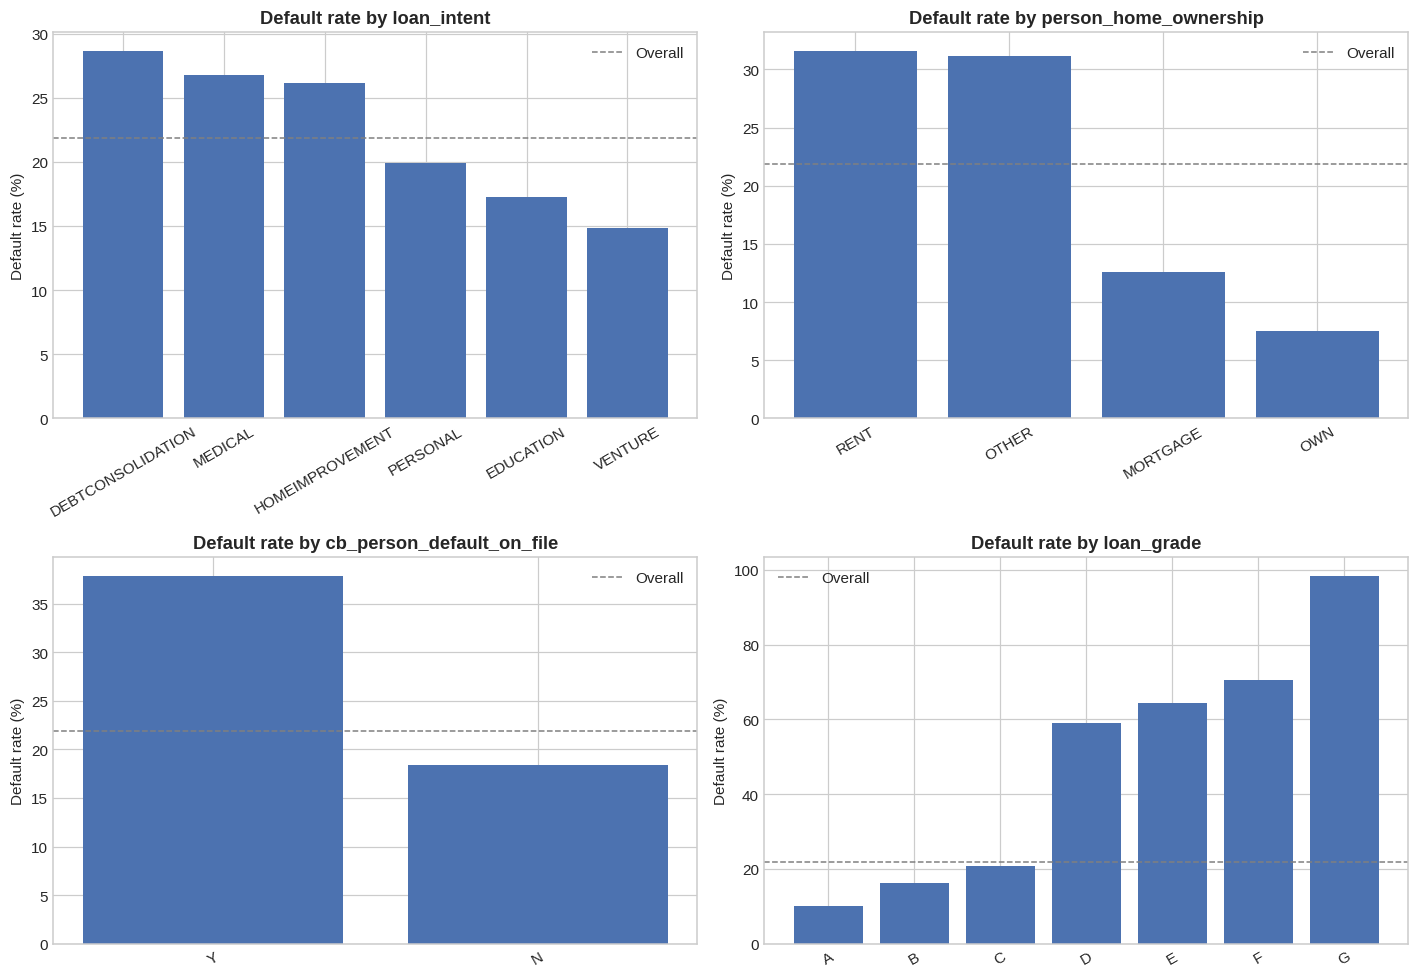

In [10]:
def default_rate_plot(col, ax, order=None):
    rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    if order is not None: rate = rate.reindex(order)
    ax.bar(rate.index.astype(str), rate.values * 100, color=PALETTE[0])
    ax.axhline(df.loan_status.mean() * 100, ls="--", c="grey", lw=1, label="Overall")
    ax.set_ylabel("Default rate (%)"); ax.set_title(f"Default rate by {col}")
    ax.tick_params(axis="x", rotation=30); ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
default_rate_plot("loan_intent", axes[0, 0])
default_rate_plot("person_home_ownership", axes[0, 1])
default_rate_plot("cb_person_default_on_file", axes[1, 0])
default_rate_plot("loan_grade", axes[1, 1], order=list("ABCDEFG"))
plt.tight_layout(); plt.show()

**Observations**

* **Loan purpose:** debt consolidation, medical and home improvement loans default more often than education or venture loans.
* **Home ownership:** renters default far more than owners or mortgage holders, consistent with weaker financial buffers.
* **Previous default:** a default on record roughly doubles the default rate.
* **Loan grade:** default rates climb steeply from A to G. This looks like a powerful predictor, but grade is assigned by the lender **after** assessing the borrower, so it partly encodes the answer. Section 6 measures this leakage.

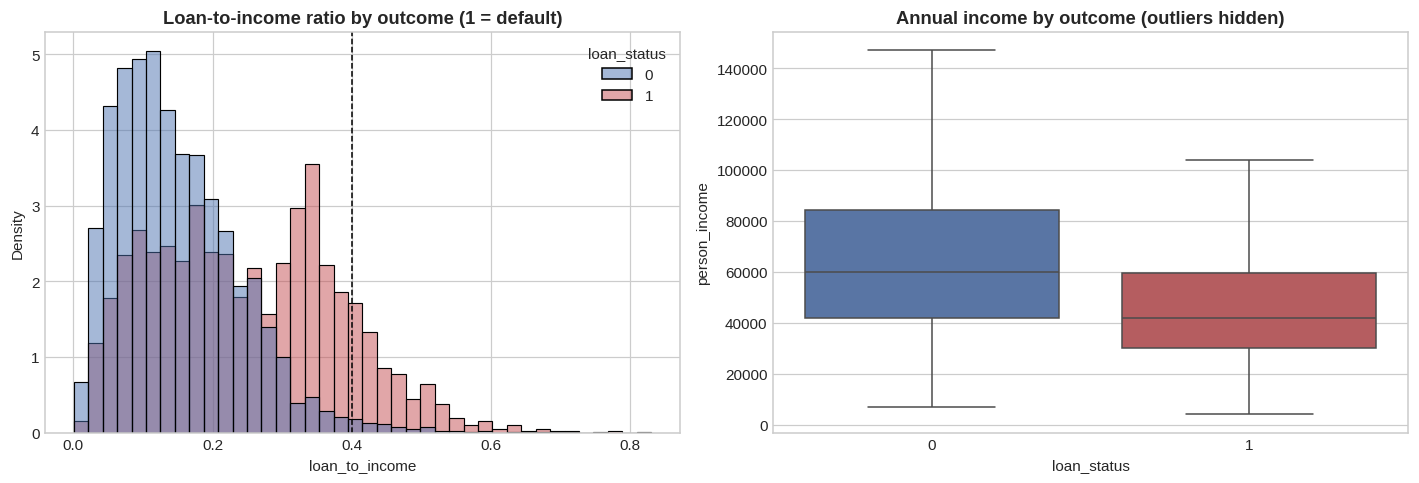

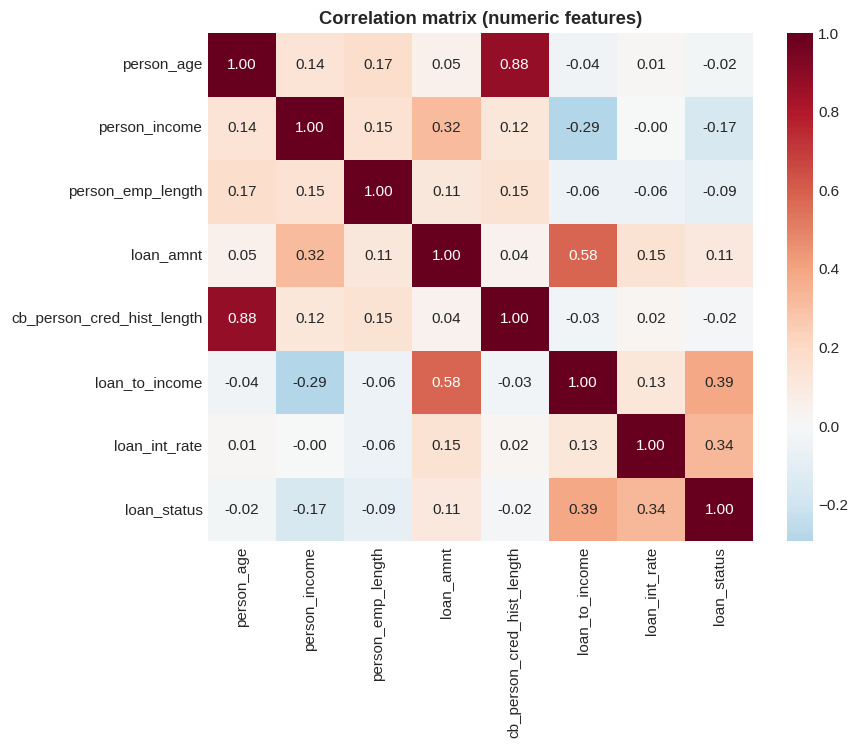

In [11]:
eda = lm.add_features(df)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=eda, x="loan_to_income", hue="loan_status", bins=40, stat="density",
             common_norm=False, palette=[PALETTE[0], PALETTE[3]], ax=axes[0])
axes[0].axvline(0.4, ls="--", c="k", lw=1); axes[0].set_title("Loan-to-income ratio by outcome (1 = default)")
sns.boxplot(data=eda, x="loan_status", y="person_income", showfliers=False,
            palette=[PALETTE[0], PALETTE[3]], ax=axes[1])
axes[1].set_title("Annual income by outcome (outliers hidden)")
plt.tight_layout(); plt.show()

num_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "cb_person_cred_hist_length", "loan_to_income", "loan_int_rate", "loan_status"]
plt.figure(figsize=(8, 6))
sns.heatmap(eda[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix (numeric features)"); plt.show()

**Observations**

* The **loan-to-income ratio** is the strongest customer-side signal: defaulters are concentrated above about 0.3 to 0.4, which justifies the `high_burden` flag and the policy rule used later.
* Defaulters have **lower incomes** on average.
* **Interest rate** correlates strongly with default, but like grade it is set by the lender after assessment.

## 5. Feature Engineering and Train / Validation / Test Split

Engineered features (defined in `loan_model.add_features`):

| Feature | Meaning |
|---|---|
| `loan_to_income` | Loan amount divided by annual income (repayment burden) |
| `log_income`, `log_loan` | Log transforms to reduce skew |
| `emp_to_age` | Employment stability: years employed relative to age |
| `hist_to_age` | Credit history length relative to age |
| `high_burden` | Flag: loan above 40% of income |
| `prior_default_high_burden` | Flag: previous default AND loan above 30% of income |

These use **no statistics from the data** (unlike the quantile bins in the original notebook), so they cannot leak test information and can be computed identically in the app.

The data is split **60% train, 20% validation, 20% test**, stratified by outcome. The validation set is used for early stopping, model selection, calibration and threshold choice. The test set is touched only for the final report.

In [12]:
TARGET = "loan_status"
X = df.drop(columns=[TARGET]); y = df[TARGET]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
for n, yy in [("Train", y_tr), ("Validation", y_va), ("Test", y_te)]:
    print(f"{n:<11} {len(yy):>6} rows | default rate {yy.mean():.1%}")

def make_preprocessor(include_lender_fields):
    num, cat = lm.feature_lists(include_lender_fields)
    ct = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ], verbose_feature_names_out=True, sparse_threshold=0)
    return Pipeline([("features", FunctionTransformer(lm.add_features)), ("encode", ct)])

POS_WEIGHT = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"Class weight for defaulters: {POS_WEIGHT:.2f}")

Train        19446 rows | default rate 21.9%
Validation    6482 rows | default rate 21.9%
Test          6483 rows | default rate 21.9%
Class weight for defaulters: 3.57


## 6. Model Training

All three models handle class imbalance the **same way** (defaulters weighted by about 3.6), so the comparison is fair:

1. **Logistic Regression** (`class_weight='balanced'`): transparent baseline.
2. **ANN (PyTorch)**: the original architecture (32 then 16 neurons, batch normalisation, dropout), now trained properly with mini-batches, a validation set and early stopping.
3. **XGBoost**: gradient-boosted trees, with early stopping on the validation set.

Each is trained on two feature sets: **Pre-screening** (customer inputs only, the deployable version) and **Full** (adds loan grade and interest rate, as in the original project), to measure how much of the original performance came from lender-assigned fields.

In [13]:
def evaluate(y_true, p, thr=0.5):
    pred = (p >= thr).astype(int)
    return {"ROC-AUC": roc_auc_score(y_true, p), "PR-AUC": average_precision_score(y_true, p),
            "Recall": recall_score(y_true, pred), "Precision": precision_score(y_true, pred),
            "F1": f1_score(y_true, pred)}

def train_logistic(Xtr, ytr):
    m = LogisticRegression(max_iter=3000, class_weight="balanced", C=1.0)
    return m.fit(Xtr, ytr)

def train_xgb(Xtr, ytr, Xva, yva):
    m = xgb.XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=5,
                          min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=1.0, scale_pos_weight=POS_WEIGHT, eval_metric="aucpr",
                          early_stopping_rounds=100, random_state=SEED, n_jobs=-1)
    return m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

In [14]:
class ANN(nn.Module):
    # Same architecture as the original DLM project
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(16, 1))
    def forward(self, x): return self.net(x)

def train_ann(Xtr, ytr, Xva, yva, max_epochs=150, patience=15, batch=256, verbose=True):
    torch.manual_seed(SEED)
    Xt = torch.tensor(Xtr, dtype=torch.float32); yt = torch.tensor(ytr.values, dtype=torch.float32).view(-1, 1)
    Xv = torch.tensor(Xva, dtype=torch.float32)
    model = ANN(Xt.shape[1])
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], dtype=torch.float32))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, yt), batch_size=batch,
                                         shuffle=True, generator=torch.Generator().manual_seed(SEED))
    hist, best_auc, best_state, wait = {"train_loss": [], "val_auc": []}, 0, None, 0
    for epoch in range(max_epochs):
        model.train(); total = 0
        for xb, yb in loader:
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad(): pv = torch.sigmoid(model(Xv)).numpy().ravel()
        auc = roc_auc_score(yva, pv)
        hist["train_loss"].append(total / len(Xt)); hist["val_auc"].append(auc)
        if auc > best_auc + 1e-4:
            best_auc, wait = auc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state); model.eval()
    if verbose: print(f"ANN stopped after {epoch + 1} epochs | best validation ROC-AUC {best_auc:.4f}")
    return model, hist

def ann_predict(model, X):
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(X, dtype=torch.float32))).numpy().ravel()

In [15]:
results, store = [], {}
for fs_name, include in [("Pre-screening", False), ("Full (with grade and rate)", True)]:
    prep = make_preprocessor(include).fit(X_tr, y_tr)
    Xtr_t, Xva_t, Xte_t = prep.transform(X_tr), prep.transform(X_va), prep.transform(X_te)
    lr_m = train_logistic(Xtr_t, y_tr)
    xgb_m = train_xgb(Xtr_t, y_tr, Xva_t, y_va)
    ann_m, hist = train_ann(Xtr_t, y_tr, Xva_t, y_va, verbose=True)
    preds = {"Logistic Regression": (lr_m.predict_proba(Xva_t)[:, 1], lr_m.predict_proba(Xte_t)[:, 1]),
             "ANN (PyTorch)": (ann_predict(ann_m, Xva_t), ann_predict(ann_m, Xte_t)),
             "XGBoost": (xgb_m.predict_proba(Xva_t)[:, 1], xgb_m.predict_proba(Xte_t)[:, 1])}
    for m_name, (pva, pte) in preds.items():
        results.append({"Feature set": fs_name, "Model": m_name, "Split": "Validation", **evaluate(y_va, pva)})
        results.append({"Feature set": fs_name, "Model": m_name, "Split": "Test", **evaluate(y_te, pte)})
    store[fs_name] = dict(prep=prep, Xtr=Xtr_t, Xva=Xva_t, Xte=Xte_t, lr=lr_m, xgb=xgb_m,
                          ann=ann_m, hist=hist, preds=preds)

res = pd.DataFrame(results)
res.round(3)

ANN stopped after 79 epochs | best validation ROC-AUC 0.8637
ANN stopped after 83 epochs | best validation ROC-AUC 0.9268


,Feature set,Model,Split,ROC-AUC,PR-AUC,Recall,Precision,F1
0,Pre-screening,Logistic Regression,Validation,0.830,0.651,0.735,0.461,0.567
1,Pre-screening,Logistic Regression,Test,0.828,0.644,0.717,0.469,0.567
2,Pre-screening,ANN (PyTorch),Validation,0.864,0.755,0.679,0.617,0.646
3,Pre-screening,ANN (PyTorch),Test,0.861,0.752,0.663,0.623,0.643
4,Pre-screening,XGBoost,Validation,0.903,0.824,0.757,0.647,0.698
5,Pre-screening,XGBoost,Test,0.905,0.819,0.750,0.653,0.698
6,Full (with grade and rate),Logistic Regression,Validation,0.885,0.733,0.804,0.567,0.665
7,Full (with grade and rate),Logistic Regression,Test,0.887,0.741,0.791,0.566,0.660
8,Full (with grade and rate),ANN (PyTorch),Validation,0.927,0.873,0.755,0.832,0.791
9,Full (with grade and rate),ANN (PyTorch),Test,0.921,0.861,0.726,0.837,0.777


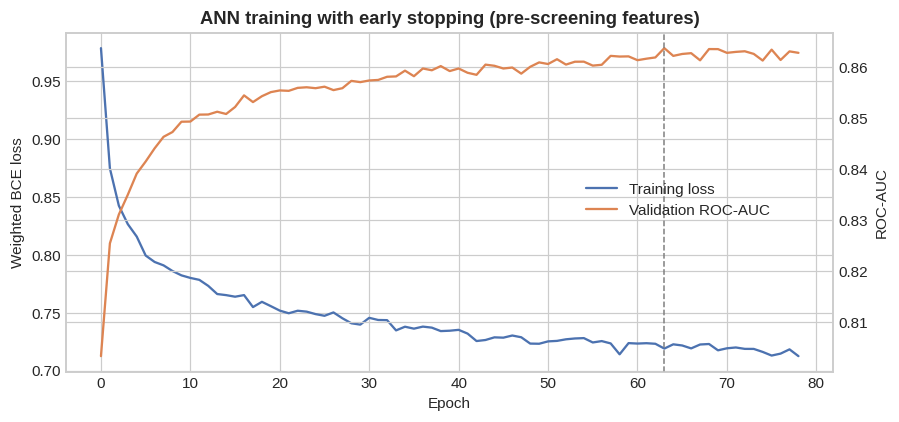

In [16]:
h = store["Pre-screening"]["hist"]
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(h["train_loss"], c=PALETTE[0], label="Training loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Weighted BCE loss")
ax2 = ax1.twinx(); ax2.plot(h["val_auc"], c=PALETTE[1], label="Validation ROC-AUC"); ax2.set_ylabel("ROC-AUC")
best = int(np.argmax(h["val_auc"])); ax2.axvline(best, ls="--", c="grey", lw=1)
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5)); plt.title("ANN training with early stopping (pre-screening features)")
plt.show()

The original project trained for 30 full-batch epochs while the loss was still falling (about 1.08 to 0.95), with no validation check. With mini-batches and early stopping, the ANN now trains until the validation score stops improving and then restores its best weights, which addresses the "validation loss is needed" limitation noted in the original notebook.

## 7. Model Comparison

In [17]:
test = res[res.Split == "Test"].drop(columns="Split")
pivot = test.pivot(index="Model", columns="Feature set", values=["ROC-AUC", "PR-AUC", "Recall"]).round(3)
pivot

ROC-AUC                \
Feature set         Full (with grade and rate) Pre-screening   
Model                                                          
ANN (PyTorch)                            0.921         0.861   
Logistic Regression                      0.887         0.828   
XGBoost                                  0.948         0.905   

                                        PR-AUC                \
Feature set         Full (with grade and rate) Pre-screening   
Model                                                          
ANN (PyTorch)                            0.861         0.752   
Logistic Regression                      0.741         0.644   
XGBoost                                  0.901         0.819   

                                        Recall                
Feature set         Full (with grade and rate) Pre-screening  
Model                                                         
ANN (PyTorch)                            0.726         0.663  
Logistic Regression                      0.791         0.717  
XGBoost                                  0.786         0.750

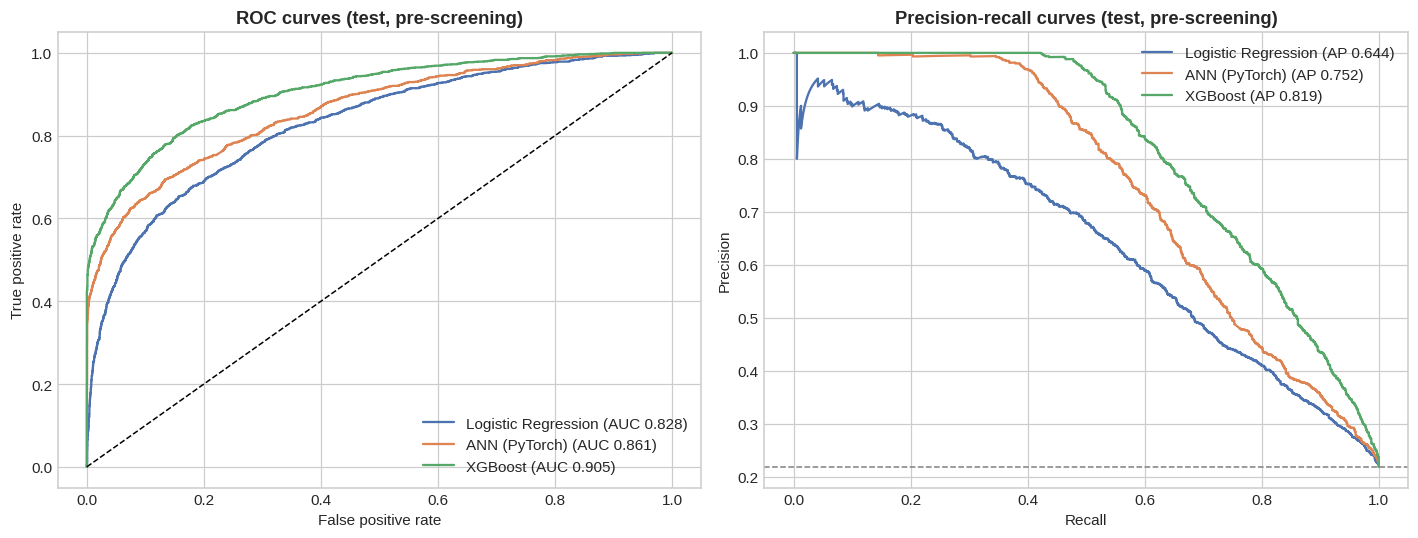

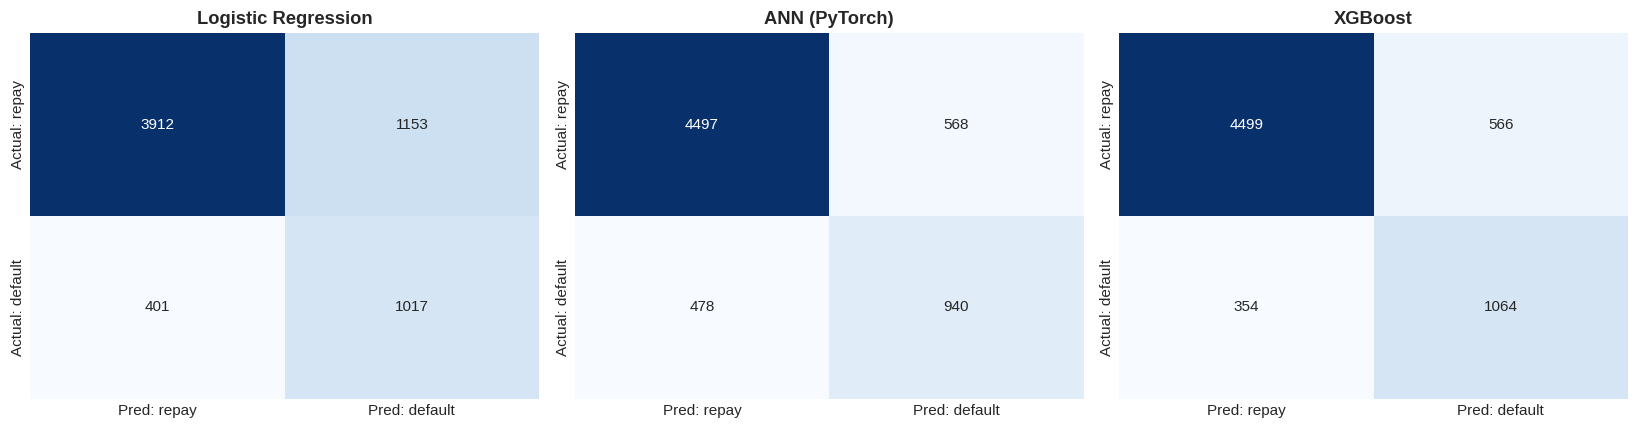

In [18]:
s = store["Pre-screening"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (name, (_, pte)), c in zip(s["preds"].items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_te, pte); prec, rec, _ = precision_recall_curve(y_te, pte)
    axes[0].plot(fpr, tpr, c=c, label=f"{name} (AUC {roc_auc_score(y_te, pte):.3f})")
    axes[1].plot(rec, prec, c=c, label=f"{name} (AP {average_precision_score(y_te, pte):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves (test, pre-screening)")
axes[1].axhline(y_te.mean(), ls="--", c="grey", lw=1); axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (test, pre-screening)")
for a in axes: a.legend(loc="best")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (_, pte)) in zip(axes, s["preds"].items()):
    cm = confusion_matrix(y_te, (pte >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: repay", "Pred: default"], yticklabels=["Actual: repay", "Actual: default"])
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [19]:
# Model selection rule (decided before looking at the test set):
# highest validation PR-AUC on the PRE-SCREENING features. PR-AUC is preferred to ROC-AUC
# because only about 22% of applicants default.
val_pre = res[(res.Split == "Validation") & (res["Feature set"] == "Pre-screening")].set_index("Model")
print(val_pre[["ROC-AUC", "PR-AUC"]].round(4).sort_values("PR-AUC", ascending=False))
BEST = val_pre["PR-AUC"].idxmax()
print("\nSelected model:", BEST)

leak = test.set_index(["Model", "Feature set"])["ROC-AUC"].unstack()
leak["AUC lost without lender fields"] = leak["Full (with grade and rate)"] - leak["Pre-screening"]
leak.round(3)

                     ROC-AUC  PR-AUC
Model                               
XGBoost               0.9031  0.8242
ANN (PyTorch)         0.8637  0.7553
Logistic Regression   0.8295  0.6511

Selected model: XGBoost


Feature set,Full (with grade and rate),Pre-screening,AUC lost without lender fields
Model,,,
ANN (PyTorch),0.921,0.861,0.060
Logistic Regression,0.887,0.828,0.059
XGBoost,0.948,0.905,0.042


**Interpretation**

* **XGBoost is the strongest model** on both feature sets, and it is also the lightest to deploy (no PyTorch needed in the app, which matters on free hosting and on an Intel Mac).
* **Properly trained, the ANN does beat Logistic Regression** (test ROC-AUC 0.861 vs 0.828 on pre-screening features), so the original intuition that the ANN captures non-linear patterns was right. However, the original **evidence** for it was flawed: the ANN was class-weighted while Logistic Regression was not, and the original notebook's own ROC-AUC values (LR 0.868 vs ANN 0.84) actually pointed the other way. The gain came from training the ANN properly (mini-batches, early stopping), not from the original setup.
* **XGBoost still beats the ANN** (0.905 vs 0.861). On tabular data of this size, tree ensembles typically outperform neural networks, and this result is consistent with that.
* **Leakage matters.** Every model loses about 4 to 6 points of AUC when loan grade and interest rate are removed. Part of the original project's performance came from fields the lender sets after assessing the borrower. The pre-screening model is weaker but honest: it uses only information a customer actually has when applying.

## 8. Probability Calibration

Class weighting pushes predicted probabilities upward, so a raw score of 0.6 does not mean a 60% chance of default. Since the app will talk to customers about risk, the selected model's scores are **calibrated** with isotonic regression, fitted on the validation set.

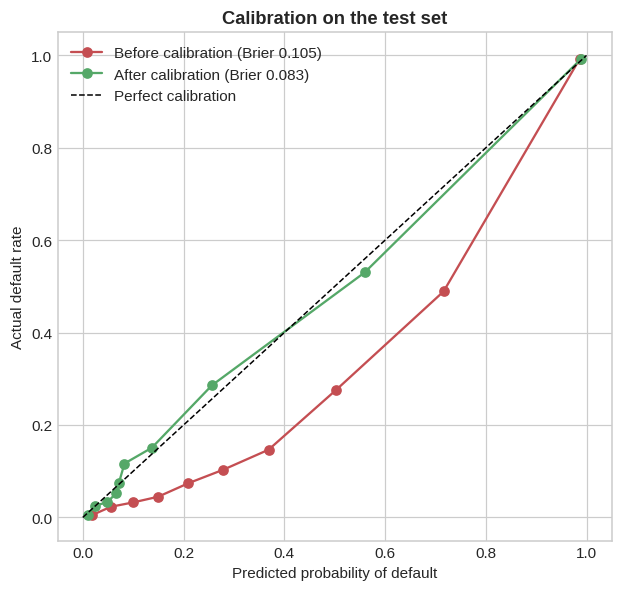

Test ROC-AUC after calibration: 0.9048 (ranking is preserved)


In [20]:
s = store["Pre-screening"]
clf = {"XGBoost": s["xgb"], "Logistic Regression": s["lr"]}.get(BEST)
if clf is None:
    raise ValueError("The ANN was selected. Deploying it would need PyTorch in the app; "
                     "see the discussion in Section 7 before continuing.")
raw_va = clf.predict_proba(s["Xva"])[:, 1]; raw_te = clf.predict_proba(s["Xte"])[:, 1]
# Bounded at 1% and 99%: no model should tell a customer that default is certain or impossible
calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.01, y_max=0.99).fit(raw_va, y_va)
cal_te = calibrator.predict(raw_te)

fig, ax = plt.subplots(figsize=(6.5, 6))
for p, lab, c in [(raw_te, "Before calibration", PALETTE[3]), (cal_te, "After calibration", PALETTE[2])]:
    frac, mean = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean, frac, "o-", c=c, label=f"{lab} (Brier {brier_score_loss(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set(xlabel="Predicted probability of default", ylabel="Actual default rate", title="Calibration on the test set")
ax.legend(); plt.show()
print(f"Test ROC-AUC after calibration: {roc_auc_score(y_te, cal_te):.4f} (ranking is preserved)")

## 9. Decision Bands and Policy Rules

Instead of a single 0.5 cut-off, the calibrated probability of default (PD) is mapped to three customer-facing bands. The thresholds are set on the **validation set** using business logic:

* **Lower threshold (t_low):** chosen so that **at least 90% of eventual defaulters** are routed to *Needs further review* or *Unlikely*. This protects the lender.
* **Upper threshold (t_high):** the lowest PD at which **at least 80% of applicants actually defaulted**. Only then is a customer told *Unlikely at this time*.

On top of the model, **hard policy rules** (in `loan_model.policy_checks`) can only make an outcome more cautious, never less. They encode lending rules of thumb: loan above 50% of income, or a previous default with a loan above 30% of income, always goes to review. Inputs outside the range seen in training also go to review, because the model has little evidence for such applicants.

In [21]:
cal_va = calibrator.predict(raw_va)
t_low = float(np.quantile(cal_va[y_va.values == 1], 0.10))
t_high = None
for t in np.unique(cal_va):
    sel = cal_va >= t
    if sel.sum() >= 30 and y_va.values[sel].mean() >= 0.80:
        t_high = float(t); break
print(f"t_low  = {t_low:.3f}  (90% of validation defaulters are at or above this)")
print(f"t_high = {t_high:.3f}  (at least 80% default rate at or above this)")

band_te = np.array([lm.model_band(p, t_low, t_high) for p in cal_te])
bt = pd.DataFrame({"band": [lm.BANDS[b] for b in band_te], "default": y_te.values})
summary = bt.groupby("band").agg(applicants=("default", "size"), actual_default_rate=("default", "mean"))
summary["share_of_applicants"] = summary.applicants / len(bt)
summary["share_of_all_defaulters"] = bt.groupby("band")["default"].sum() / bt.default.sum()
summary = summary.reindex(lm.BANDS)
summary.style.format({"actual_default_rate": "{:.1%}", "share_of_applicants": "{:.1%}",
                      "share_of_all_defaulters": "{:.1%}"})

t_low  = 0.083  (90% of validation defaulters are at or above this)
t_high = 0.419  (at least 80% default rate at or above this)


,applicants,actual_default_rate,share_of_applicants,share_of_all_defaulters
band,,,,
Likely eligible,3376,3.6%,52.1%,8.7%
Needs further review,2037,20.4%,31.4%,29.3%
Unlikely at this time,1070,82.1%,16.5%,62.0%


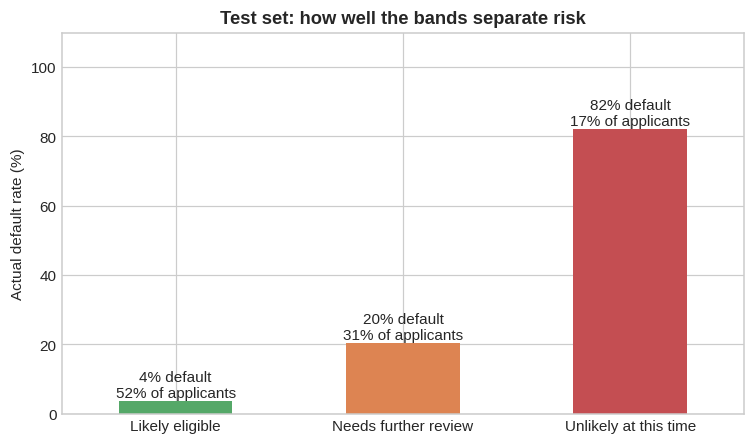

In [22]:
ax = (summary["actual_default_rate"] * 100).plot.bar(color=[PALETTE[2], PALETTE[1], PALETTE[3]], figsize=(8, 4.5), rot=0)
for i, (r, sh) in enumerate(zip(summary.actual_default_rate, summary.share_of_applicants)):
    ax.text(i, r * 100 + 1, f"{r:.0%} default\n{sh:.0%} of applicants", ha="center")
ax.set_ylabel("Actual default rate (%)"); ax.set_xlabel(""); ax.set_ylim(0, 110)
ax.set_title("Test set: how well the bands separate risk"); plt.show()

In [23]:
# How often do the rules of thumb DISAGREE with the model? (test set)
training_ranges = {c: [round(float(X_tr[c].quantile(0.001)), 2), round(float(X_tr[c].quantile(0.999)), 2)]
                   for c in ["person_age", "person_income", "person_emp_length", "cb_person_cred_hist_length"]}
emp_median = float(X_tr.person_emp_length.median())
rows = []
for (_, a), mb, yv in zip(X_te.iterrows(), band_te, y_te.values):
    a = a.to_dict()
    if pd.isna(a["person_emp_length"]):
        a["person_emp_length"] = emp_median
    lti = a["loan_amnt"] / a["person_income"]
    _, reasons = lm.policy_checks(a, training_ranges)
    rows.append({"model_band": mb, "default": yv,
                 "Loan above 50% of income": lti > 0.5,
                 "Past default and loan above 30% of income": a["cb_person_default_on_file"] == "Y" and lti > 0.3,
                 "Outside training range": any("outside the range" in r for r in reasons)})
chk = pd.DataFrame(rows)
rule_table = []
for rule in ["Loan above 50% of income", "Past default and loan above 30% of income", "Outside training range"]:
    t = chk[chk[rule]]
    dis = t[t.model_band == 0]
    rule_table.append({"Rule": rule, "Applicants triggered": len(t),
                       "Model already cautious": f"{(t.model_band > 0).mean():.1%}" if len(t) else "n/a",
                       "Disagreements (model said eligible)": len(dis),
                       "Default rate when triggered": f"{t.default.mean():.1%}" if len(t) else "n/a"})
pd.DataFrame(rule_table)

,Rule,Applicants triggered,Model already cautious,Disagreements (model said eligible),Default rate when triggered
0,Loan above 50% of income,60,85.0%,9,76.7%
1,Past default and loan above 30% of income,164,95.1%,8,75.0%
2,Outside training range,34,50.0%,17,29.4%


**Reading this table (rules of thumb vs the model)**

* For the two **repayment-burden rules**, the model already agrees in the large majority of cases (it had already placed the applicant in *Needs review* or *Unlikely*). This is reassuring: the model has learned the same logic a credit officer would apply.
* In the **small number of disagreements**, where the model said *Likely eligible* but a rule of thumb fired, the rule wins and the applicant goes to review. Since applicants who trigger these rules default at around 75%, overriding the model here is the safe choice.
* The **out-of-range rule** fires for unusual profiles (for example, very high incomes or long careers). These are not necessarily risky, but the model has seen very few such applicants, so a human should check them rather than trusting the score.

## 10. Explainability with SHAP

SHAP shows how much each input pushed a prediction up or down. Globally, it reveals what the model relies on; for a single applicant, it explains the result in terms the customer can understand. The app uses the same values (computed directly by XGBoost) to generate its plain-language explanation.

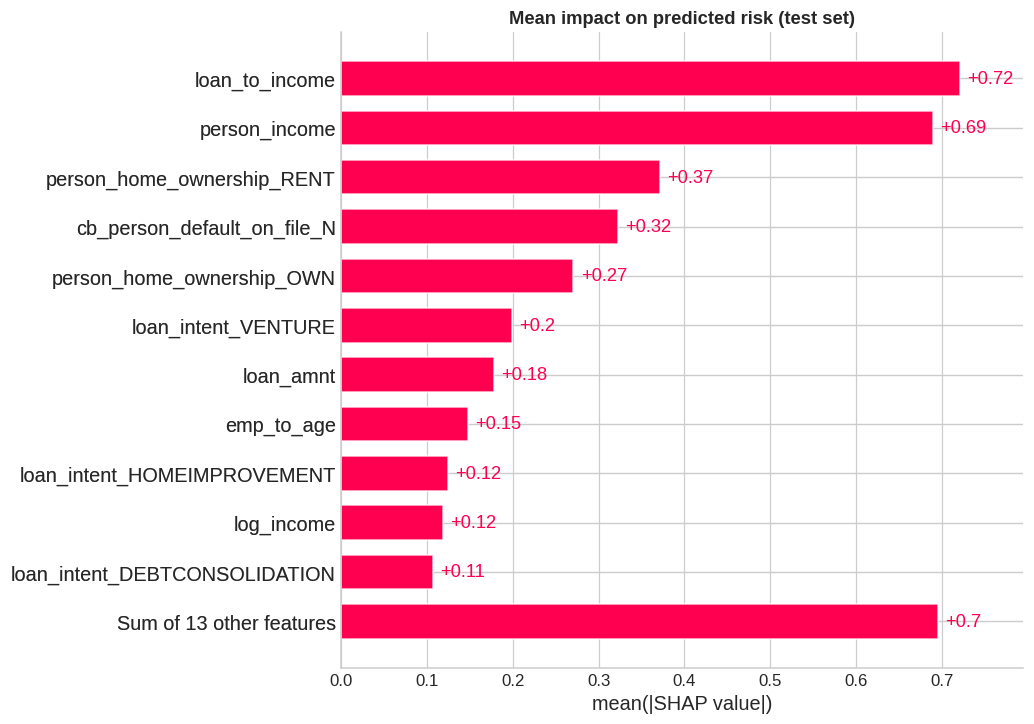

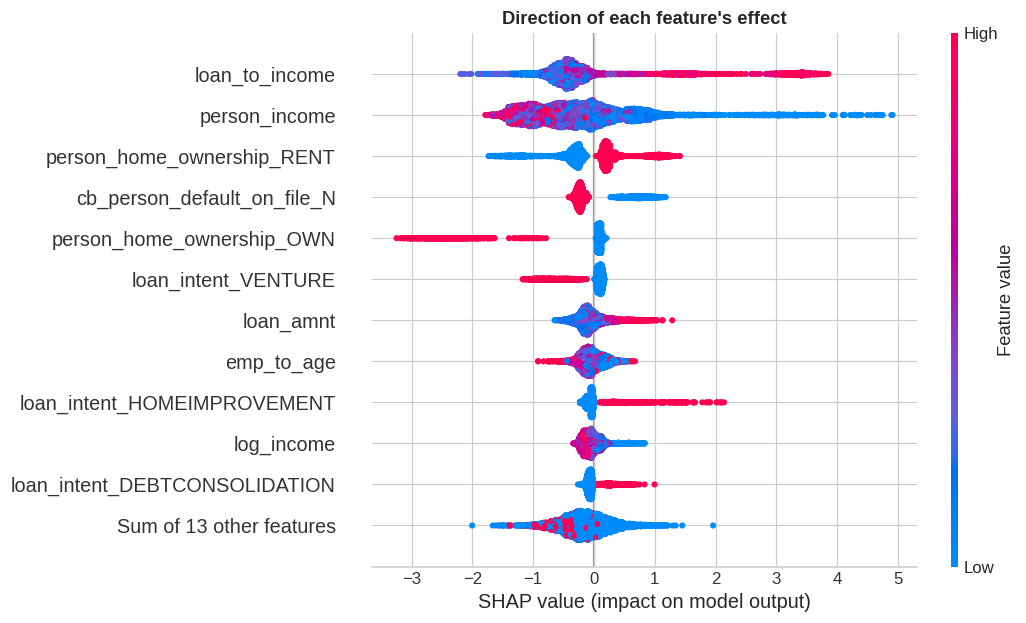

In [24]:
feat_names = s["prep"].named_steps["encode"].get_feature_names_out()
nice = [n.split("__", 1)[1] for n in feat_names]
Xte_df = pd.DataFrame(s["Xte"], columns=nice)
explainer = shap.TreeExplainer(clf) if BEST == "XGBoost" else shap.LinearExplainer(clf, s["Xtr"])
sv = explainer(Xte_df)
shap.plots.bar(sv, max_display=12, show=False); plt.title("Mean impact on predicted risk (test set)"); plt.show()
shap.plots.beeswarm(sv, max_display=12, show=False); plt.title("Direction of each feature's effect"); plt.show()

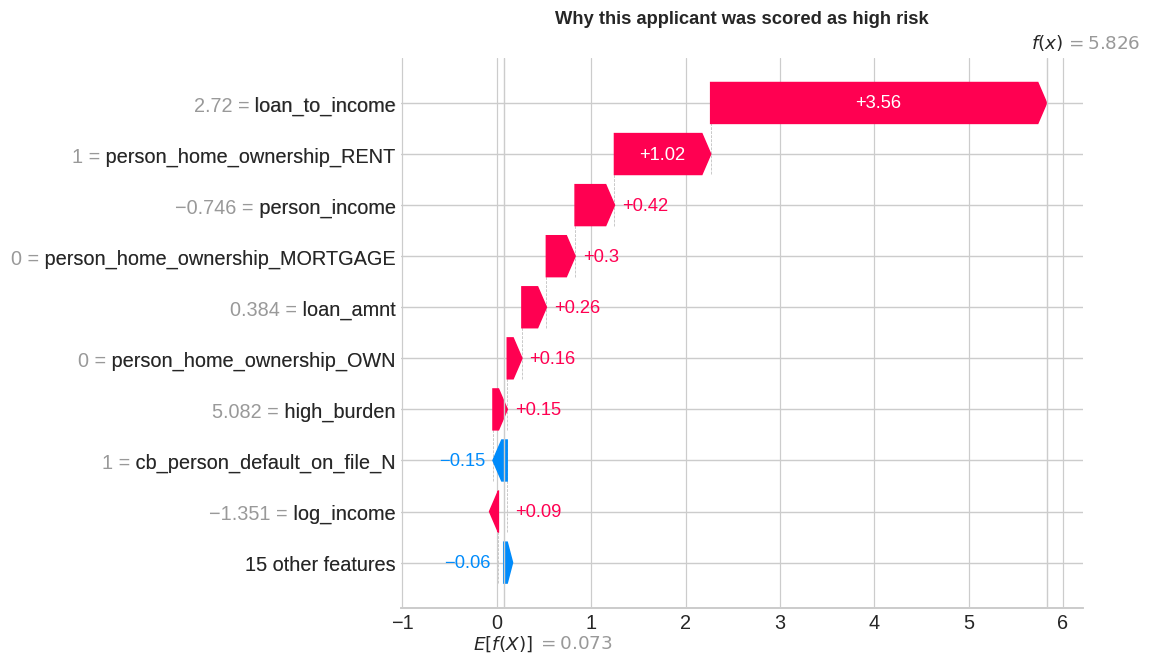

In [25]:
# One applicant who defaulted and was placed in the highest band
idx = int(np.where((band_te == 2) & (y_te.values == 1))[0][0])
shap.plots.waterfall(sv[idx], max_display=10, show=False)
plt.title("Why this applicant was scored as high risk"); plt.show()

**Reading the SHAP plots**

* The loan-to-income burden, income, home ownership (renting), loan purpose and previous default are the main risk drivers, which matches credit intuition and the EDA.
* Because these drivers make business sense, the model is less likely to be relying on spurious patterns, which is important evidence when explaining outcomes to customers and evaluators.

## 11. Save the Model for the App

In [26]:
final_model = lm.LoanRiskModel(preprocessor=s["prep"], classifier=clf, calibrator=calibrator,
                               kind="xgboost" if BEST == "XGBoost" else "logistic",
                               feature_names=feat_names)
joblib.dump(final_model, "artifacts/loan_model.joblib")

test_row = res[(res.Split == "Test") & (res["Feature set"] == "Pre-screening") & (res.Model == BEST)].iloc[0]
config = {
    "model_name": BEST, "version": "1.0", "author": "Aman Aggarwal (065064)",
    "currency": "USD (demonstration dataset)",
    "t_low": round(t_low, 4), "t_high": round(t_high, 4), "bands": lm.BANDS,
    "training_ranges": training_ranges,
    "hard_limits": lm.HARD_LIMITS, "categories": lm.CATEGORIES,
    "test_metrics": {k: round(float(test_row[k]), 4) for k in ["ROC-AUC", "PR-AUC", "Recall", "Precision"]},
    "base_default_rate": round(float(y_tr.mean()), 4),
}
with open("artifacts/config.json", "w") as f:
    json.dump(config, f, indent=2)
import shutil; shutil.copy("loan_model.py", "artifacts/loan_model.py")
print(json.dumps(config, indent=2))
print("\nSaved:", os.listdir("artifacts"))

{
  "model_name": "XGBoost",
  "version": "1.0",
  "author": "Aman Aggarwal (065064)",
  "currency": "USD (demonstration dataset)",
  "t_low": 0.0828,
  "t_high": 0.4187,
  "bands": [
    "Likely eligible",
    "Needs further review",
    "Unlikely at this time"
  ],
  "training_ranges": {
    "person_age": [
      21.0,
      64.56
    ],
    "person_income": [
      8829.59,
      648000.0
    ],
    "person_emp_length": [
      0.0,
      24.0
    ],
    "cb_person_cred_hist_length": [
      2.0,
      29.0
    ]
  },
  "hard_limits": {
    "person_age": [
      18,
      100
    ],
    "person_income": [
      1000,
      10000000
    ],
    "person_emp_length": [
      0,
      60
    ],
    "loan_amnt": [
      500,
      35000
    ],
    "cb_person_cred_hist_length": [
      0,
      60
    ]
  },
  "categories": {
    "person_home_ownership": [
      "RENT",
      "MORTGAGE",
      "OWN",
      "OTHER"
    ],
    "loan_intent": [
      "EDUCATION",
      "MEDICAL",
      "VENTU

## 12. End-to-End Test: Scoring Sample Applicants

This reloads the saved model from disk (as the app will) and runs three applicants through the complete flow: validation, calibrated risk, band, policy rules and explanation. The fourth applicant has an impossible age to show validation working.

In [27]:
loaded = joblib.load("artifacts/loan_model.joblib")
cfg = json.load(open("artifacts/config.json"))

applicants = {
    "A: stable homeowner, small loan": dict(person_age=38, person_income=95000, person_emp_length=10,
        loan_amnt=8000, cb_person_cred_hist_length=12, person_home_ownership="MORTGAGE",
        loan_intent="EDUCATION", cb_person_default_on_file="N"),
    "B: young renter, moderate loan": dict(person_age=26, person_income=42000, person_emp_length=2,
        loan_amnt=12000, cb_person_cred_hist_length=3, person_home_ownership="RENT",
        loan_intent="MEDICAL", cb_person_default_on_file="N"),
    "C: renter, past default, heavy burden": dict(person_age=24, person_income=25000, person_emp_length=1,
        loan_amnt=15000, cb_person_cred_hist_length=2, person_home_ownership="RENT",
        loan_intent="DEBTCONSOLIDATION", cb_person_default_on_file="Y"),
    "D: invalid input": dict(person_age=144, person_income=50000, person_emp_length=5,
        loan_amnt=10000, cb_person_cred_hist_length=5, person_home_ownership="RENT",
        loan_intent="PERSONAL", cb_person_default_on_file="N"),
}
for name, a in applicants.items():
    r = lm.score_applicant(loaded, a, cfg)
    print("=" * 70); print(name)
    if not r["valid"]:
        print("  Rejected at validation:", r["errors"]); continue
    print(f"  Probability of default: {r['probability_of_default']:.1%}")
    print(f"  Model band: {r['model_band']}  |  Final result: {r['final_band']}")
    for reason in r["policy_reasons"]: print("  Policy rule:", reason)
    print("  Top drivers (+ raises risk, - lowers risk):")
    for f, v in r["top_drivers"]: print(f"     {f:<40} {v:+.2f}")

A: stable homeowner, small loan
  Probability of default: 2.1%
  Model band: Likely eligible  |  Final result: Likely eligible
  Top drivers (+ raises risk, - lowers risk):
     Annual income                            -1.30
     Loan purpose                             -0.33
     Home ownership                           -0.28
     Previous default on record               -0.25
     Age                                      -0.22
B: young renter, moderate loan
  Probability of default: 8.3%
  Model band: Needs further review  |  Final result: Needs further review
  Top drivers (+ raises risk, - lowers risk):
     Loan-to-income ratio                     -0.56
     Annual income                            -0.35
     Previous default on record               -0.34
     Home ownership                           +0.30
     Loan amount requested                    -0.18
C: renter, past default, heavy burden
  Probability of default: 99.0%
  Model band: Unlikely at this time  |  Final result: U

## 13. Conclusions

1. **Best model: XGBoost** on customer-available inputs. It outperforms both Logistic Regression and the ANN on ROC-AUC and PR-AUC, and it is simple to deploy.
2. **The ANN beats Logistic Regression, but only once it is trained properly.** The upgraded ANN (mini-batches, early stopping) reaches a test ROC-AUC of about 0.86 against 0.83 for Logistic Regression, while the original 30-epoch version scored 0.84 and was compared unfairly. Gradient-boosted trees remain the best choice for this kind of tabular data.
3. **Leakage was inflating the original results.** Loan grade and interest rate are decided by the lender after assessment; removing them lowers AUC but gives a model that can genuinely pre-screen applicants.
4. **Decisions use calibrated probabilities, three bands and hard policy rules**, not a single 0.5 cut-off. The bands separate risk sharply, and the rules add a human-style safety layer.
5. **SHAP explanations** confirm the model relies on sensible drivers (repayment burden, income, home ownership, loan purpose, past default) and let the app explain each result.

**Limitations**

* The data is a US dataset in dollars and does not represent Indian borrowers or bureau scores such as CIBIL; the model should not be applied to real Indian applicants without retraining on local data.
* No macroeconomic variables and no time dimension, so the model cannot anticipate economic downturns.
* Sensitive attributes such as age are used as inputs; a real deployment would need a fairness review against lending regulations.
* The outputs are indicative pre-screening results, not credit decisions.

**Next step:** these artifacts (`loan_model.joblib`, `config.json`, `loan_model.py`) power the Streamlit Loan Eligibility Pre-Screener with a Hindi and English chat and voice assistant.

---
*References: Basel Committee on Banking Supervision; scikit-learn, XGBoost, PyTorch and SHAP documentation; Lundberg and Lee (2017), "A Unified Approach to Interpreting Model Predictions".*

In [28]:
import sys, sklearn, xgboost, numpy, pandas, joblib
print("python", sys.version.split()[0])
for m in [sklearn, xgboost, numpy, pandas, joblib]:
    print(m.__name__, m.__version__)

python 3.13.15
sklearn 1.6.1
xgboost 3.4.1
numpy 2.1.3
pandas 2.2.3
joblib 1.6.0
